In [41]:
import sys
sys.path.append('../lib/')
import numpy as np
import healpy as hp
import pymaster as nmt
import pysm3
import pysm3.units as u
import matplotlib.pyplot as plt
import simu_lib as sim
import basicfunc as func

In [151]:
# PySM model to consider, d#s#

dust_type = 1
sync_type = 1
nside_pysm = 64

nside = 64
Npix = hp.nside2npix(nside)
lmax = 2*nside-1
Nlbin = 5

# Reference frequencies in GHz

nu0d = 402
nu0s = 40

In [152]:
# Compute dust moments maps

mask = np.float64(hp.read_map('../masks/HFI_Mask_GalPlane-apo0_2048_R2.00.fits', field=3))
mask = hp.ud_grade(mask, nside_pysm)
mask[mask<0.5], mask[mask>0.5] = 0, 1
mask_apo = hp.read_map('../masks/mask_fsky0.7_nside64_aposcale10.npy')

sky = pysm3.Sky(nside_pysm, preset_strings=[f'd{dust_type}'], output_unit=u.uK_CMB)
dust = sky.components[0]
beta_map = dust.mbb_index.value
T_map = dust.mbb_temperature.value

A_map = sky.get_emission(nu0d * u.GHz).value
A_complex = A_map[1] + 1j * A_map[2]

beta_bar = np.average(beta_map[mask==1], weights=A_complex[mask==1]).real
T_bar = 1 / np.average(1/T_map[mask==1], weights=A_complex[mask==1]).real

w2b = A_complex * (beta_map-beta_bar)**2

In [153]:
# Compute moment spectra

b = nmt.NmtBin.from_lmax_linear(lmax, nlb=Nlbin)
leff = b.get_effective_ells()

f2 = nmt.NmtField(mask_apo, None, spin=2, lmax=lmax, purify_b=True)
w2 = nmt.NmtWorkspace()
w2.compute_coupling_matrix(f2, f2, b)

f0 = nmt.NmtField(mask_apo, None, spin=0, lmax=lmax)
w0 = nmt.NmtWorkspace()
w0.compute_coupling_matrix(f0, f0, b)

f_A = nmt.NmtField(mask_apo, A_map[1:], purify_b=True)
f_w2b = nmt.NmtField(mask_apo, [w2b.real, w2b.imag], purify_b=True)
f_beta = nmt.NmtField(mask_apo, [beta_map])

Cl_AA = sim.compute_master(f_A, f_A, w2)[3]
Cl_Aw2b = sim.compute_master(f_A, f_w2b, w2)[3]
Cl_bb = sim.compute_master(f_beta, f_beta, w0)[0]

sigma_b2 = np.sum((2*leff+1) / (4*np.pi) * Cl_bb)
sigma_b2 = np.std(beta_map)**2

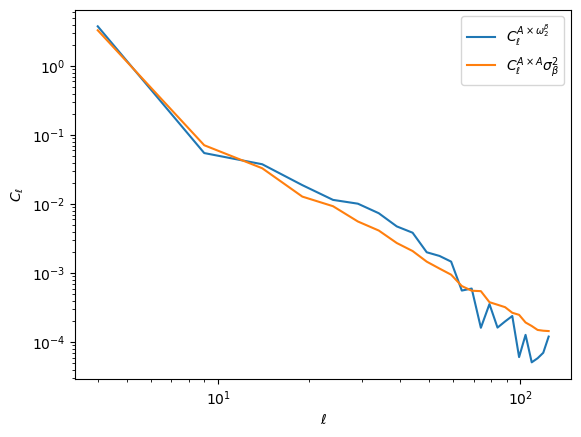

In [157]:
plt.plot(leff, Cl_Aw2b, label=r'$C_\ell^{A \times \omega_2^\beta}$')
plt.plot(leff, Cl_AA * sigma_b2, label=r'$C_\ell^{A \times A} \sigma_{\beta}^2$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
plt.legend()
plt.show()